In [1]:
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from xeofs.single import EOF
import pandas as pd
import gdown

In [2]:
if torch.cuda.is_available():
  print("GPU detected")
  device = torch.device("cuda")
else:
  print("No GPU detected")
  device = torch.device("cpu")

No GPU detected


In [3]:
from pathlib import Path
from typing import Tuple

# Environment detection
def in_colab() -> bool:
    try:
        from IPython import get_ipython  # type: ignore
        return "google.colab" in str(get_ipython())
    except Exception:
        return False  # not even in IPython
        
# Download helper for both files
def ensure_data(
    sst_download_url: str,
    enso_download_url: str,
    sst_local_path: str,
    enso_local_path: str,
) -> Tuple[Path, Path]:
    """
    sst_download_url: public Google Drive URL or any HTTP(S) URL for SSTs
    enso_download_url: public Google Drive URL or any HTTP(S) URL for ENSO indices
    sst_local_path: where to store the file locally (relative or absolute) for SSTs
    enso_local_path: where to store the file locally (relative or absolute) for ENSO
    """
    def _download_if_needed(url: str, local_path: str) -> Path:
        p = Path(local_path)
        if p.exists():
            return p
        p.parent.mkdir(parents=True, exist_ok=True)

        # Prefer gdown for Google Drive; fallback to requests. [web:19][web:43]
        try:
            gdown.download(url=url, output=str(p), quiet=False)
        except ImportError:
            import requests
            r = requests.get(url, stream=True)
            r.raise_for_status()
            with open(p, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
        return p

    sst_path = _download_if_needed(sst_download_url, sst_local_path)
    enso_path = _download_if_needed(enso_download_url, enso_local_path)
    return sst_path, enso_path


#  Unified loader for SST + ENSO
def load_sst_and_enso(scc = False):
    """
    If on SCC:
        - SST: use SCC path (your Datasets dir)
        - ENSO: use SCC path /projectnb/.../oscillation_indices.nc
    Else (Colab or local):
        - Download both SST and ENSO from Google Drive into local files (if needed).
    Returns
    -------
    ssts : xr.DataArray  (stacked lat/lon -> pixel, 1982–2022)
    enso : np.ndarray    (enso_34 values, 1982–2022)
    """
    # Google Drive direct-download URLs (uc?id=...) [web:19][web:43]
    sst_gdoc_url = "https://drive.google.com/uc?id=1pyGgAgnH3W--disqAERRTHsGpv7OnZa2"
    enso_gdoc_url = "https://drive.google.com/uc?id=1u-fnCfh3QOsOfwVkeCnF60wGRBL6dP9J"

    if in_colab():
        # Colab / local: download from Google Drive into current dir (or adjust as desired)
        sst_nc_path, enso_nc_path = ensure_data(
            sst_download_url=sst_gdoc_url,
            enso_download_url=enso_gdoc_url,
            sst_local_path="EMD_Detrended_SST_anoms.nc",
            enso_local_path="oscillation_indices.nc",
        )

    if scc:
        # SCC paths and loading
        sst_nc_path = Path("/projectnb/modislc/users/cneher/Datasets/EMD_Detrended_SST_anoms.nc")
        enso_nc_path = Path("/projectnb/modislc/users/cneher/Datasets/oscillation_indices.nc")
    else:
        sst_nc_path, enso_nc_path = ensure_data(
            sst_download_url=sst_gdoc_url,
            enso_download_url=enso_gdoc_url,
            sst_local_path="EMD_Detrended_SST_anoms.nc",
            enso_local_path="oscillation_indices.nc",
        )
    # Load SSTs: same as your existing pipeline. [web:88][web:91]
    ds_sst = xr.open_dataset(sst_nc_path).sel(time=slice("1982-01-01", "2022-12-31"))
    ssts = (
        ds_sst["__xarray_dataarray_variable__"]
        .drop_vars(["spatial_ref", "month"])
        .stack(pixel=("lat", "lon"))
        .dropna(dim="pixel", how="any")
    )

    # Load ENSO. [web:93][web:96]
    ds_indices = xr.open_dataset(enso_nc_path).sel(time=slice("1982-01-01", "2022-12-31"))

    return ssts, ds_indices

In [7]:
ssts, indices = load_sst_and_enso()
enso = indices["enso_34"].values

Downloading...
From (original): https://drive.google.com/uc?id=1pyGgAgnH3W--disqAERRTHsGpv7OnZa2
From (redirected): https://drive.google.com/uc?id=1pyGgAgnH3W--disqAERRTHsGpv7OnZa2&confirm=t&uuid=79f8d867-e58d-483d-9a4c-293ee24f92aa
To: /Users/callumneher/506-Final-Proj/EMD_Detrended_SST_anoms.nc
100%|██████████| 118M/118M [00:17<00:00, 6.73MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1u-fnCfh3QOsOfwVkeCnF60wGRBL6dP9J
To: /Users/callumneher/506-Final-Proj/oscillation_indices.nc
100%|██████████| 106k/106k [00:00<00:00, 2.81MB/s]


In [8]:
class TimeSeriesDataset(Dataset):
    def __init__(self, stacked_da):  # expects xarray DataArray with shape (site, time)
        self.data = torch.tensor(stacked_da.values, dtype=torch.float32)
        # If you have targets, do similar
    def __len__(self):
        return self.data.shape[0]
    def __getitem__(self, idx):
        return self.data[idx]  # or (self.data[idx], self.targets[idx])

# Build dataset
dataset = TimeSeriesDataset(ssts)
data_loader = DataLoader(dataset, batch_size=32, shuffle=True)
inference_loader = DataLoader(dataset, batch_size = 32, shuffle = False)

***Building encoder***

In [9]:
class Encoder(nn.Module):
    def __init__(self, input_dim=492, hidden_dim1=1024, hidden_dim2 = 256, latent_dim=20):
        super(Encoder, self).__init__()
        self.fc0 = nn.Linear(input_dim, hidden_dim1)
        self.bn0 = nn.BatchNorm1d(hidden_dim1)
        self.fc1 = nn.Linear(hidden_dim1, hidden_dim2)
        self.bn1 = nn.BatchNorm1d(hidden_dim2)
        self.fc_mu = nn.Linear(hidden_dim2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim2, latent_dim)

    def forward(self, x):
        x = self.fc0(x)
        x = self.bn0(x)
        x = torch.relu(x)
    
        h = self.fc1(x)
        h = self.bn1(h)
        h = torch.relu(h)
    
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

In [10]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=20, hidden_dim1=1024, hidden_dim2 = 256, output_dim=492):
        super(Decoder, self).__init__()
        self.fc0 = nn.Linear(latent_dim, hidden_dim2)
        self.bn0 = nn.BatchNorm1d(hidden_dim2)
        self.fc1 = nn.Linear(hidden_dim2, hidden_dim1)
        self.bn1 = nn.BatchNorm1d(hidden_dim1)
        self.fc2 = nn.Linear(hidden_dim1, output_dim)

    def forward(self, z):
        q = self.fc0(z)
        q = self.bn0(q)
        q = torch.relu(q)
    
        h = self.fc1(q)
        h = self.bn1(h)
        h = torch.relu(h)
    
        out = self.fc2(h)
        return out  # no BN or activation here unless you explicitly want it

In [11]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, input_dim=492, hidden_dim1=1024, hidden_dim2 = 256, latent_dim=20):
        super(VariationalAutoencoder, self).__init__()
        self.encoder = Encoder(input_dim = input_dim, hidden_dim1 = hidden_dim1, hidden_dim2 = hidden_dim2, latent_dim = latent_dim)
        self.decoder = Decoder(latent_dim = latent_dim, hidden_dim1 = hidden_dim1, hidden_dim2 = hidden_dim2, output_dim = input_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decoder(z)
        return x_hat, mu, logvar


In [12]:
def compute_inv_cov_diag(data_loader, device, regularization=1e-3):
    """
    Diagonal approximation of inverse covariance - numerically stable & fast
    Equivalent to weighted MSE where each feature has its own variance
    """
    print("Computing diagonal inverse covariance (stable approach)...")
    
    all_data = []
    for batch in data_loader:
        all_data.append(batch.cpu())
    
    all_data = torch.cat(all_data, dim=0)
    print(f"Dataset shape: {all_data.shape}")
    
    # Compute per-feature variance + regularization
    feature_vars = all_data.var(dim=0) + regularization
    
    # Inverse variance (diagonal elements of Σ⁻¹)
    inv_vars = 1.0 / feature_vars
    
    # Create diagonal matrix
    inv_cov_diag = torch.diag(inv_vars).to(device)
    
    del all_data
    torch.cuda.empty_cache()
    
    print(f"Diagonal inv_cov computed! Shape: {inv_cov_diag.shape}")
    return inv_cov_diag

In [13]:
def reconstruction_loss(x_true, x_recon, inv_cov):
    """
    Robust weighted MSE for diagonal inv_cov. Works with ANY batch size.
    Replace ALL calls to mahalanobis_recon_loss with this.
    """
    diff = x_recon - x_true  # (batch_size, 492)
    
    # Extract diagonal (inv_vars): shape (492,)
    inv_vars = torch.diag(inv_cov)  # (492,)
    
    # Element-wise weighted squared error: (batch_size, 492)
    weighted_sq_error = (diff ** 2) * inv_vars.unsqueeze(0)  # Broadcasting!
    
    # Mean over all features and batch
    return torch.mean(weighted_sq_error)

In [14]:
def evaluate_loss(autoencoder, dataloader, device):
    autoencoder.eval()
    total_loss = 0
    total_samples = 0
    
    with torch.no_grad():
        for x in dataloader:
            x = x.to(device)
            x_hat, mu, logvar = autoencoder(x)
            recon_loss = ((x - x_hat)**2).sum(dim=1)  # sum over features per sample
            kl_loss = kl_divergence(mu, logvar)
            batch_loss = (recon_loss + kl_loss).sum().item()
            
            total_loss += batch_loss
            total_samples += x.size(0)
    avg_loss = total_loss / total_samples
    return avg_loss


In [15]:
def kl_divergence(mu, logvar):
    # mu, logvar: tensors of shape (batch_size, latent_dim)
    # Returns: mean KL divergence per sample (scalar)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    return kl.mean()

def train(autoencoder, data, inv_cov, patience = 5, epochs=20, beta = 1.0):
    opt = torch.optim.Adam(autoencoder.parameters(), lr=0.01)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.95)
    best_loss = float('inf')
    epochs_no_improve = 0
    
    for epoch in range(epochs):
        autoencoder.train()
        train_loss_sum = 0.0
        n_batches = 0
        
        for batch in data:
            x = batch.to(device) # GPU
            opt.zero_grad()
            
            x_hat, mu, logvar = autoencoder(x)
            recon_loss = reconstruction_loss(x, x_hat, inv_cov)
            kl_loss = kl_divergence(mu, logvar)
            loss = recon_loss + beta * kl_loss
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(autoencoder.parameters(), max_norm=0.5)
            opt.step() 
            
            
            train_loss_sum += loss.item()
            n_batches += 1
        avg_train_loss = train_loss_sum / n_batches
        scheduler.step()

        print(f'Epoch {epoch:3d} | Train Loss: {avg_train_loss:.4f}')

        
        # Early stopping check
        if avg_train_loss < best_loss:
            best_loss = avg_train_loss
            epochs_no_improve = 0
            best_model_state = autoencoder.state_dict()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                autoencoder.load_state_dict(best_model_state)
                print("Best model state restored")
                print(f"Best loss: {best_loss:.4f}")
                break
    return autoencoder

In [16]:
# Before big computations:
import gc
gc.collect()
torch.cuda.empty_cache()

# Check memory:
print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.1f}GB allocated, "
      f"{torch.cuda.memory_reserved()/1e9:.1f}GB reserved")

GPU memory: 0.0GB allocated, 0.0GB reserved


In [17]:
inv_cov = compute_inv_cov_diag(data_loader, device, regularization=1e-3)

Computing diagonal inverse covariance (stable approach)...
Dataset shape: torch.Size([492, 39735])
Diagonal inv_cov computed! Shape: torch.Size([39735, 39735])


In [18]:
vae = VariationalAutoencoder(input_dim = ssts.shape[1], hidden_dim1 = 1024, hidden_dim2 = 256, latent_dim = 2).to(device)

In [19]:
trained_vae = train(vae, data_loader, inv_cov, patience = 10, epochs = 100, beta = 0.1)

Epoch   0 | Train Loss: 2.5372
Epoch   1 | Train Loss: 1.2901
Epoch   2 | Train Loss: 1.1364
Epoch   3 | Train Loss: 1.0357
Epoch   4 | Train Loss: 1.0146
Epoch   5 | Train Loss: 0.9994
Epoch   6 | Train Loss: 0.9955
Epoch   7 | Train Loss: 0.9974
Epoch   8 | Train Loss: 0.9907
Epoch   9 | Train Loss: 0.9982
Epoch  10 | Train Loss: 0.9974
Epoch  11 | Train Loss: 0.9970
Epoch  12 | Train Loss: 0.9894
Epoch  13 | Train Loss: 0.9823
Epoch  14 | Train Loss: 0.9881
Epoch  15 | Train Loss: 0.9934
Epoch  16 | Train Loss: 0.9913
Epoch  17 | Train Loss: 0.9916
Epoch  18 | Train Loss: 0.9880
Epoch  19 | Train Loss: 0.9737
Epoch  20 | Train Loss: 0.9802
Epoch  21 | Train Loss: 0.9804
Epoch  22 | Train Loss: 0.9845
Epoch  23 | Train Loss: 0.9830
Epoch  24 | Train Loss: 0.9825
Epoch  25 | Train Loss: 0.9776
Epoch  26 | Train Loss: 0.9767
Epoch  27 | Train Loss: 0.9914
Epoch  28 | Train Loss: 0.9811
Epoch  29 | Train Loss: 0.9792
Early stopping triggered after 30 epochs.
Best model state restored
Be

In [20]:
@torch.no_grad()
def latent_sst(autoencoder, dataloader, device):
    autoencoder.eval()  # put in eval mode

    latents_mu = []
    latents_logvar = []

    with torch.no_grad():
        for x in dataloader:
            x = x.to(device)
            mu, logvar = autoencoder.encoder(x)  # only run encoder
            latents_mu.append(mu.cpu())
            latents_logvar.append(logvar.cpu())

    # Concatenate results to a tensor of shape (num_samples, latent_dim)
    latents_mu = torch.cat(latents_mu, dim=0)
    latents_logvar = torch.cat(latents_logvar, dim=0)

    return latents_mu, latents_logvar

In [21]:
# Get latent representations Z
latents_mu, latents_logvar = latent_sst(trained_vae, inference_loader, device)
Z = latents_mu.numpy()  # Shape: (n_pixels, latent_dim)

print(f"Z Shape: {Z.shape}")

Z Shape: (492, 2)


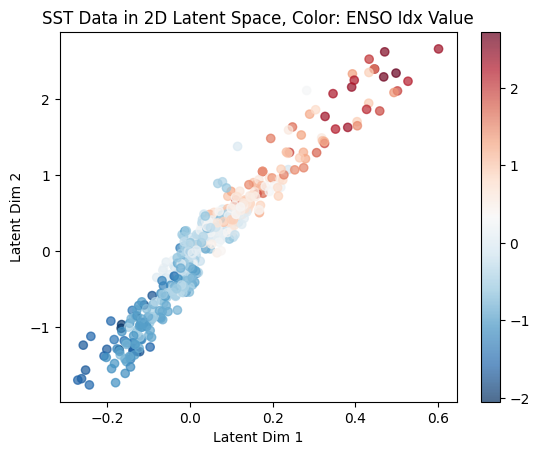

In [22]:
# plot in 2d space
## Best for 2 latent dims
plt.scatter(Z[:,0], Z[:,1], alpha=0.7, cmap = 'RdBu_r', c = enso)
plt.xlabel('Latent Dim 1'); plt.ylabel('Latent Dim 2')
plt.colorbar()
plt.title('SST Data in 2D Latent Space, Color: ENSO Idx Value')
plt.show()

In [23]:
def plot_latent_ts(all_z):
    num_ts = all_z.shape[1]
    fig, axs = plt.subplots(num_ts+1,1, figsize = (20,5*num_ts+5), layout = 'constrained')
    fig.suptitle(F"{num_ts} Latent Time Series from VAE")
    for i in range(num_ts):
        axs[i].plot(indices.time, all_z[:,i])
        axs[i].set_title(f"Latent Dim {i+1} Time Series")
    
    axs[-1].plot(indices.time, enso, 'r')
    axs[-1].set_title("ENSO 3.4 Index")
    plt.show()

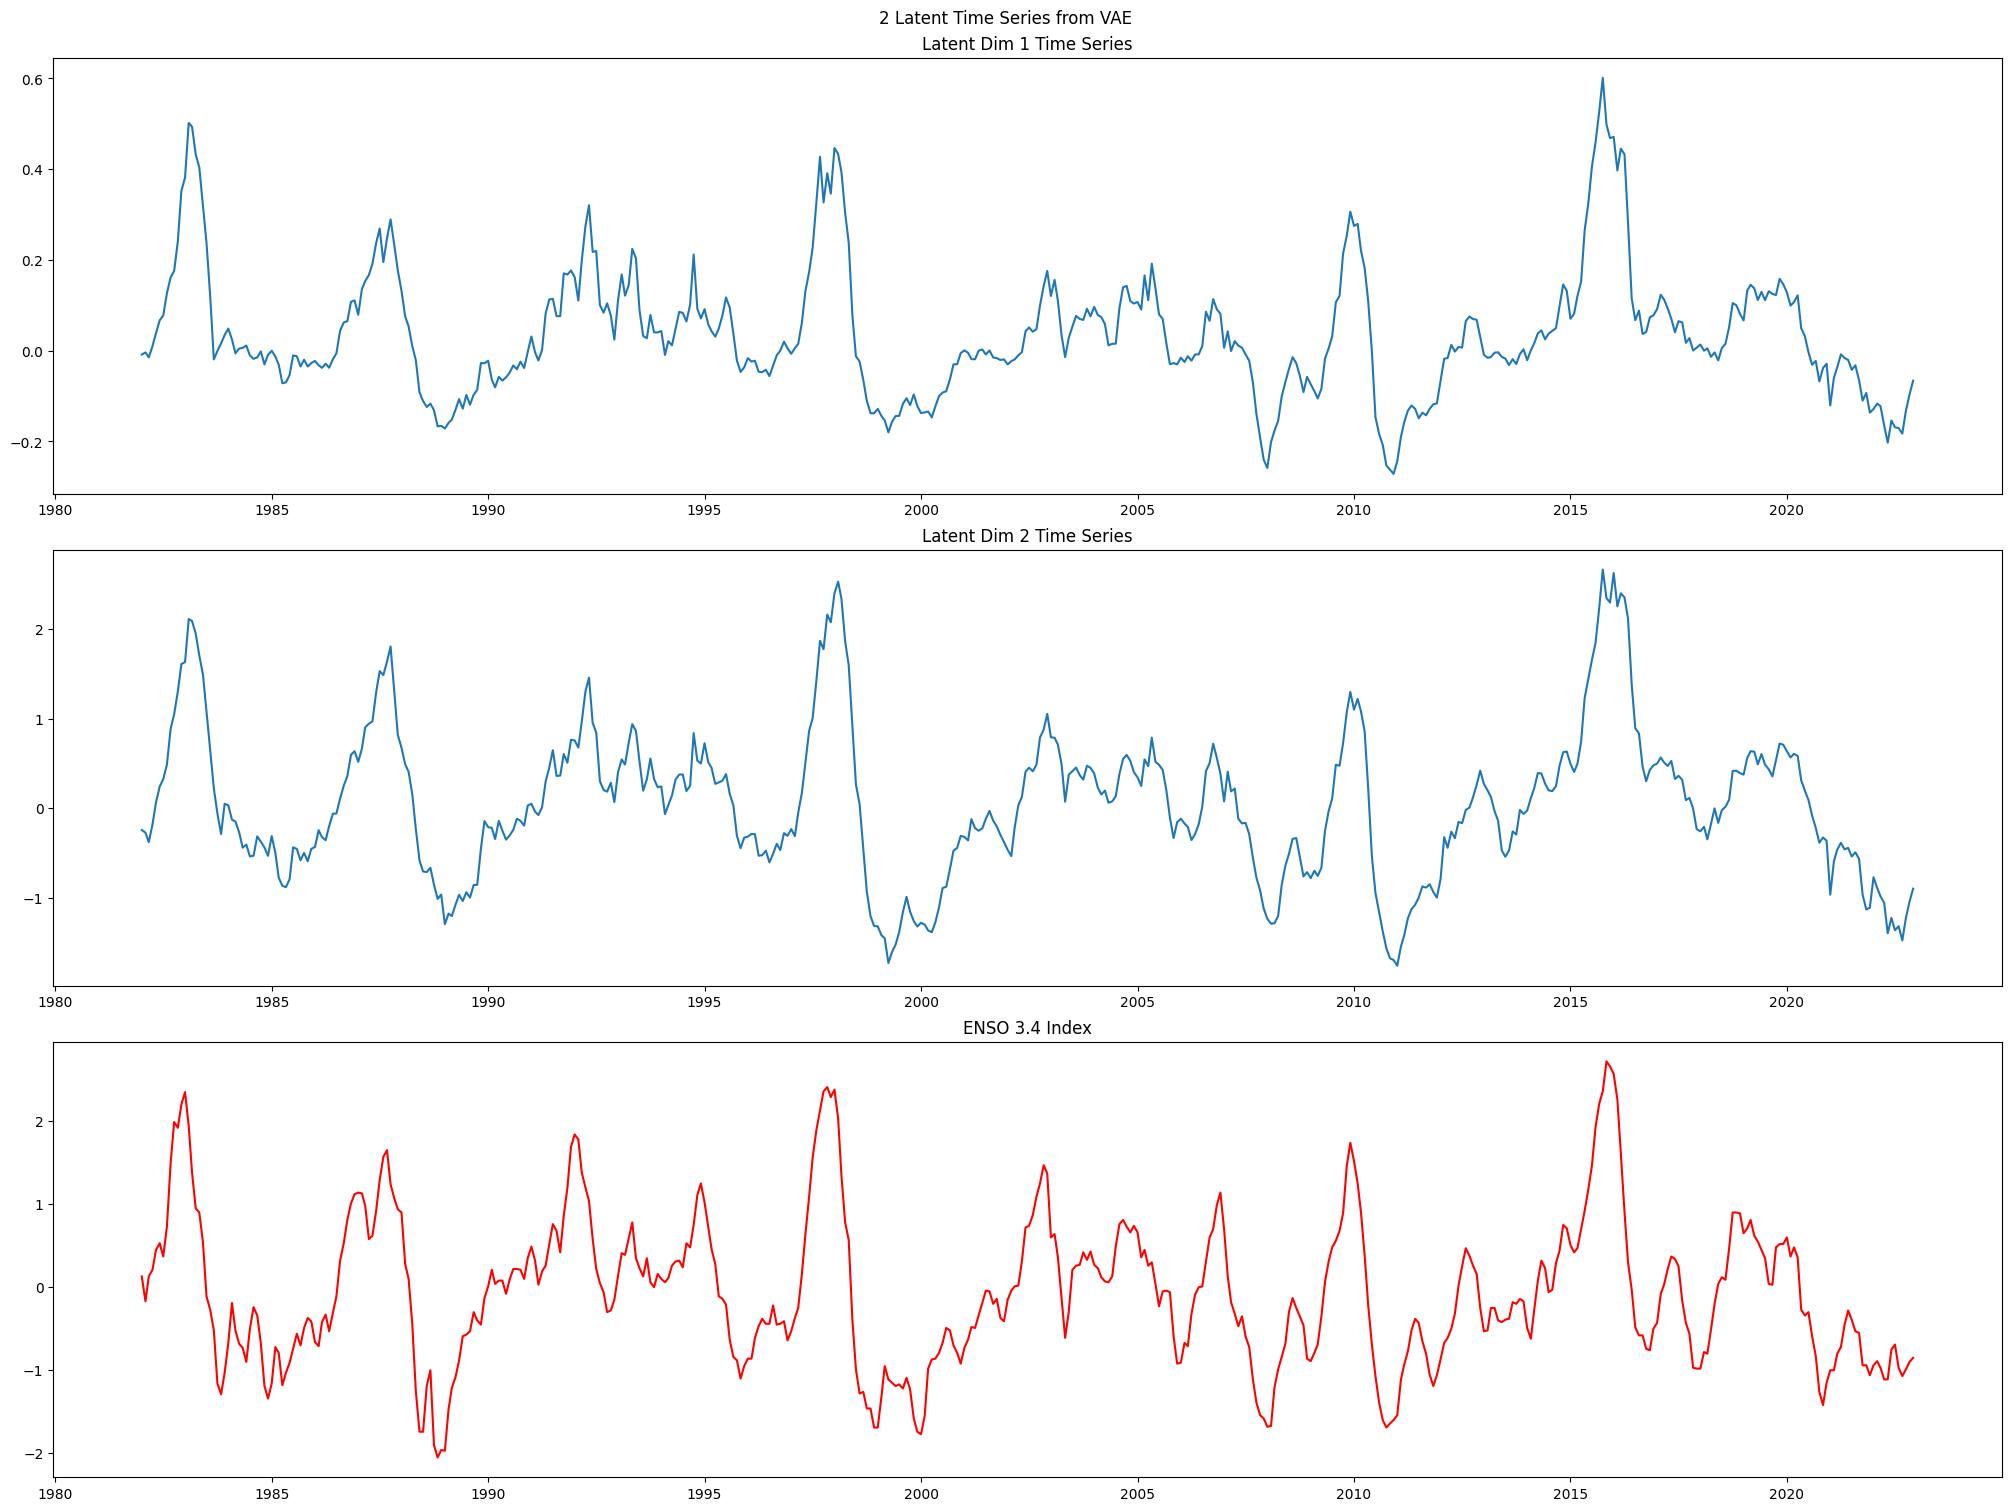

In [24]:
plot_latent_ts(Z)

In [25]:
# Plot the correlation between latent TS and all pixels

def plot_latent_corrs(ssts, all_z):
    num_ts = all_z.shape[1]
    fig, axs = plt.subplots(num_ts,1, figsize = (10,7.5*num_ts), layout = 'constrained')
    for i in range(num_ts):
        da = xr.DataArray(data = all_z[:,i], coords = {'time': ssts.time})
        xr.corr(ssts, da, dim = 'time').unstack().plot(ax = axs[i])
        axs[i].set_title(F"Latent Dim {i+1} TS Correlations to SST Pixel TS")

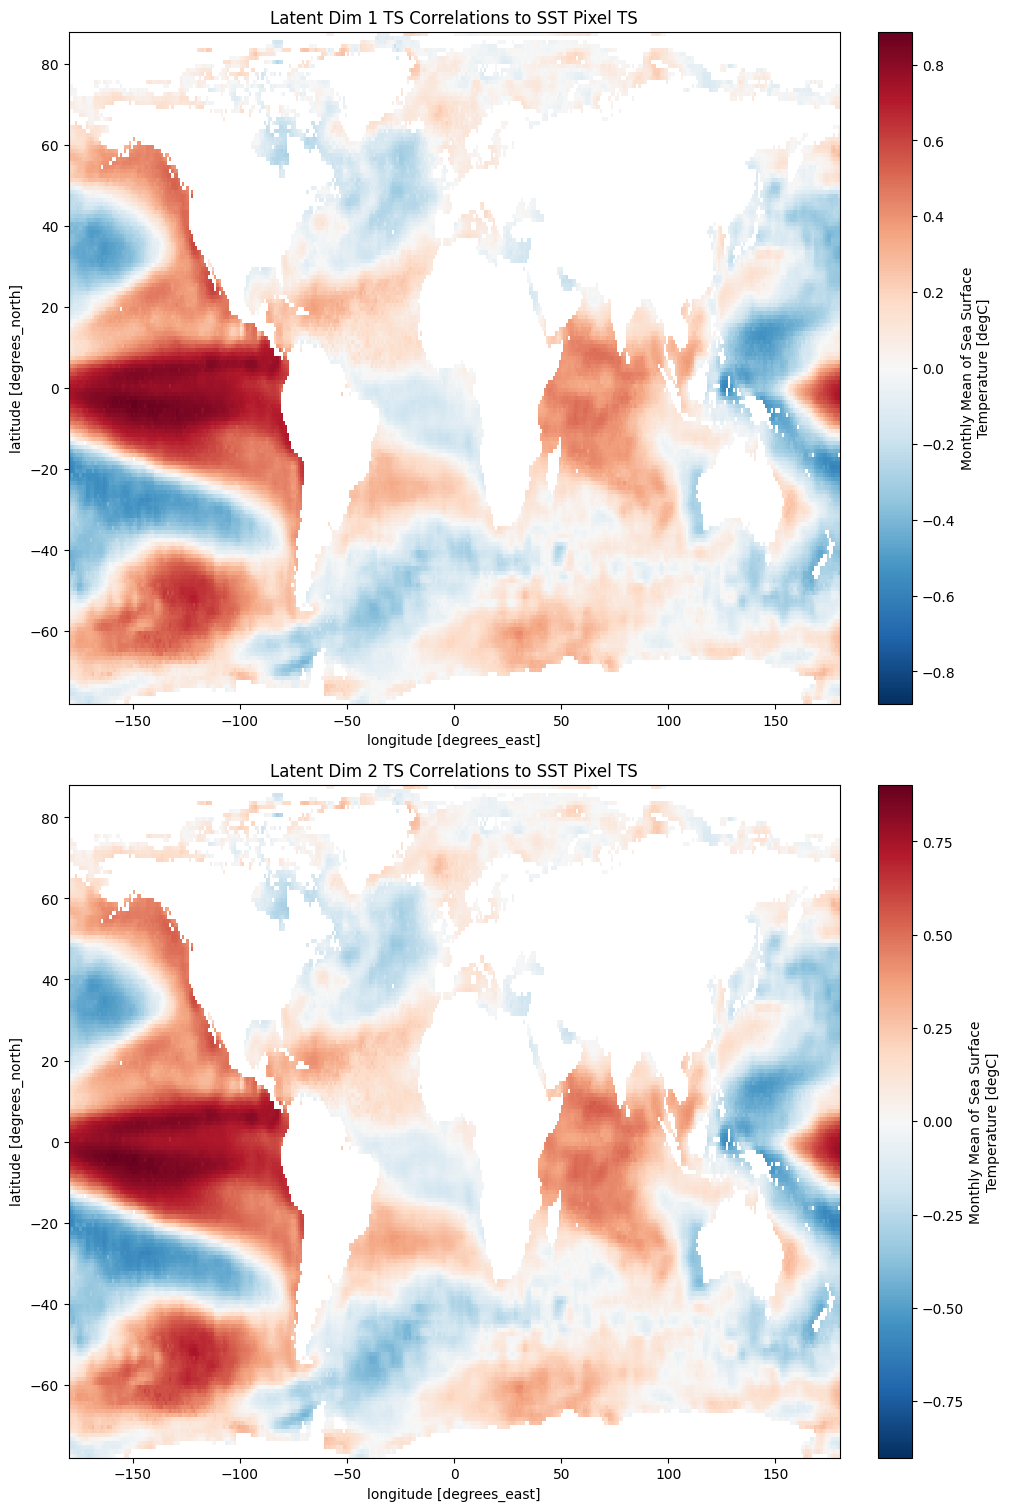

In [26]:
plot_latent_corrs(ssts, Z)

# Create Spatial Loading Videos

In [27]:
# Calculate gradients
@torch.no_grad()
def get_decoder_gradients_forward(vae, Z, device, eps=1e-3):
    """Forward finite differences: f(z + eps*e_d)/eps (faster, good accuracy)"""
    vae.eval()
    Z = Z.to(device)
    n_samples, latent_dim = Z.shape
    output_dim = ssts.shape[1]
    
    W_grads = torch.zeros(n_samples, output_dim, latent_dim, device=device)
    
    print("Computing forward-mode decoder gradients...")
    for d in range(latent_dim):
        if (d+1) % 2 == 0:
            print(f"  Latent dim {d+1}/{latent_dim}")
        
        e_d = torch.zeros_like(Z)
        e_d[:, d] = 1.0
        
        # Single perturbation per dimension
        perturbed = vae.decoder(Z + eps * e_d)
        W_grads[:, :, d] = perturbed / eps
    
    return W_grads.cpu().numpy()


In [28]:
# Compute gradients for each time point
print("\nComputing gradients")
W_array = get_decoder_gradients_forward(trained_vae, latents_mu, device)
print(f"W shape: {W_array.shape}")  # (39735, 492, 10)


Computing gradients
Computing forward-mode decoder gradients...
  Latent dim 2/2
W shape: (492, 39735, 2)


In [29]:
from moviepy import VideoClip

def create_moviepy_loading_maps_with_timeseries(W_array, ssts, latent_idx, output_path, fps=4):
    """MoviePy version with map + time series + moving red dot"""
    loadings = W_array[:, :, latent_idx]  # (time_points, spatial_locations)
    n_timepoints = loadings.shape[0]
    
    # Precompute spatial mean time series for efficiency
    mean_loading_time_series = loadings.mean(axis=1)  # shape (time_points,)
    times = ssts.time.values
    pixel_coords = ssts.pixel
    
    vmin = np.percentile(loadings, 1)
    vmax = np.percentile(loadings, 99)
    
    def make_frame(t):
        i = int(t * fps) % n_timepoints  # Current frame index
        
        # Create figure with 2 subplots (map + time series)
        fig, (ax_map, ax_ts) = plt.subplots(1, 2, figsize=(16, 7))
        
        # MAP: Spatial loading at time i
        loading_i = loadings[i, :]
        loading_da = xr.DataArray(
            loading_i,
            coords={'pixel': pixel_coords},
            dims='pixel'
        ).unstack('pixel')
        
        loading_da.plot(
            ax=ax_map,
            cmap='RdBu_r',
            vmin=vmin,
            vmax=vmax,
            add_colorbar=False
        )
        ax_map.set_title(
            f'Latent Dimension {latent_idx + 1} Loadings\n'
            f'Time: {pd.Timestamp(times[i]).strftime("%Y-%m-%d")}',
            fontsize=14, fontweight='bold'
        )
        ax_map.set_xlabel('Longitude')
        ax_map.set_ylabel('Latitude')
        
        # TIME SERIES: Full series + red dot at current time
        ax_ts.plot(times, mean_loading_time_series, color='blue', linewidth=2, label='Mean Loading')
        ax_ts.scatter(times[i], mean_loading_time_series[i], color='red', s=100, 
                     zorder=5, edgecolors='darkred', linewidth=2, label='Current Time')
        
        # Time series formatting
        ax_ts.set_xlim(times[0], times[-1])
        y_min, y_max = mean_loading_time_series.min(), mean_loading_time_series.max()
        ax_ts.set_ylim(y_min - 0.1 * abs(y_min), y_max + 0.1 * abs(y_max))
        ax_ts.set_title('Spatial Mean Loading Time Series', fontsize=14, fontweight='bold')
        ax_ts.set_xlabel('Time')
        ax_ts.set_ylabel('Mean Loading')
        ax_ts.grid(True, alpha=0.3)
        ax_ts.legend()
        
        # Date formatting for readability
        import matplotlib.dates as mdates
        ax_ts.xaxis.set_major_locator(mdates.YearLocator(2))
        ax_ts.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.setp(ax_ts.xaxis.get_majorticklabels(), rotation=45)
        
        plt.tight_layout()
        
        # Convert to RGB buffer
        fig.canvas.draw()
        rgba_buffer = np.asarray(fig.canvas.buffer_rgba())
        rgb_buffer = rgba_buffer[:, :, :3]  # Drop alpha channel
        plt.close(fig)
        return rgb_buffer
    
    # Create and save video
    video = VideoClip(make_frame, duration=n_timepoints/fps)
    video.write_videofile(
        output_path, 
        fps=fps, 
        codec='libx264', 
        audio=False
    )
    video.close()
    print(f"Video saved: {output_path}")

In [30]:
for idx in range(2):
    create_moviepy_loading_maps_with_timeseries(W_array, ssts, idx, f'latent_dim_{idx}.mp4', fps=8)

MoviePy - Building video latent_dim_0.mp4.
MoviePy - Writing video latent_dim_0.mp4



MoviePy - Done !
MoviePy - video ready latent_dim_0.mp4
Video saved: latent_dim_0.mp4
MoviePy - Building video latent_dim_1.mp4.
MoviePy - Writing video latent_dim_1.mp4



MoviePy - Done !
MoviePy - video ready latent_dim_1.mp4
Video saved: latent_dim_1.mp4


# Comparing Linear PCA Reconstruction to VAE Reconstruction

In [31]:
# Filler basic pca function
def linear_pca(data, n_pcs = 8):
    pca = EOF(n_modes = n_pcs)
    pcs = pca.fit_transform(data, dim = 'time')
    return pca, pcs

# Plot important stats for a given pc
def plot_pc_info(pca, pcs, mode = 'all'):
    if mode == 'all':
        exp_vars = pca.explained_variance_ratio().values
        n_pcs = len(exp_vars)
        fig, ax = plt.subplots(nrows = n_pcs, ncols = 2, figsize = (10, 4*n_pcs), layout = 'constrained')
        fig.suptitle(f"{n_pcs} PCs of SST data; Total Exp. Var: {sum(exp_vars):.4f}")
        for i in range(n_pcs):
            pcs.sel(pcs = i+1).plot(ax = ax[i,0])
            pca.components().sel(mode = i+1).unstack().plot(ax = ax[i,1])
            ax[i,0].set_title(f"PC{i+1} of SST data")
            ax[i,1].set_title(f"Explained Var: {exp_vars[i]:.4f}")
    else:
        fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (10,8), layout = 'constrained')
        fig.suptitle(f"PC{mode} of SST data and components, exp. var: {pca.explained_variance_ratio()[mode].values:.4f}")
        pcs.sel(mode = mode).plot(ax = ax[0])
        ax[0].set_title("")
        ax[1].set_title("")
        pca.components().sel(mode = mode).plot(ax = ax[1])

In [32]:
sst_pca, sst_pcs = linear_pca(ssts, n_pcs = 2)

In [33]:
# Linear reconstruction
pca_reconstructed = sst_pca.inverse_transform(sst_pcs)

In [34]:
# VAE reconstruction
reconstruct_list = []
with torch.no_grad():
    for x in inference_loader:
        x = x.to(device)
        x_hat, mu, logvar = trained_vae(x)  # Full forward pass!
        reconstruct_list.append(x_hat.cpu())
vae_reconstructed = torch.cat(reconstruct_list, dim = 0).numpy()

In [35]:
mse_pca = np.mean((ssts - pca_reconstructed)**2)
rmse_pca = mse_pca**0.5
mse_vae = np.mean((ssts - vae_reconstructed)**2)
rmse_vae = mse_vae**0.5

print(f"RMSE Linear PCA: {rmse_pca.values:.4f}")
print(f"RMSE VAE: {rmse_vae.values:.4f}")

RMSE Linear PCA: 0.8746
RMSE VAE: 0.9139
